# Kolmogorov Flow (2D)

A periodic box driven by a **sinusoidal body force**, `f_x = xi sin(k pi y)`,
with a small divergence-free noise component in `y`. The laminar answer is the
sinusoidal velocity profile the forcing implies; it is unstable above a critical
forcing, so the shear layers roll up into vortices, merge, and settle into a
statistically steady state with a few large structures. The noise is there only
to break the symmetry -- without it the laminar profile is a (numerically)
stable fixed point and nothing happens.

The forcing is a **dynamic boundary condition**, not an initial condition: it is
re-evaluated every step by `forcing(...)` inside
`kolmogorovCase.initialConditions`, which builds a `BoundaryCondition` with a
`forcingFunctions` list over the fluid SDF. Two details in there matter if you
change it:

- positions are mapped through `getPeriodicPositions` first, so the force is
  continuous across the periodic wrap rather than jumping at the seam;
- the noise interpolator is built on **CPU** (it is sampled with numpy-side
  Perlin) and only its output crosses to the device, which is why `seed` and the
  octave parameters produce exactly reproducible runs.

`--obstacle` adds a rigid body in the middle of the box -- a circle by default,
any of the `SHAPE_PRESETS` shapes via `--obstacleShape`, placed and turned by
the other four `obstacle*` knobs. Off by default; the case is the forcing.

![](outputs/08-kolmogorovFlow.gif)


## Every knob, and what it does

The parameters cell below is the whole command line of `08-kolmogorov-flow.py` written out:
`CaseSpec` fields first, then `kolmogorovCase.params` -- the case's own physics knobs,
each of which is also a `--flag`. Anything not named there keeps the value in
`kolmogorovCase.defaults`/`.params`.

**Discretisation, time stepping and output** (`CaseSpec` fields, shared by every case)

| field | this notebook | what it does |
|---|---|---|
| `nx` | `128` | particles across the domain; the spacing is `dx = L / nx` |
| `dim` | `2` | this case is 2D |
| `L` | `2.0` | side of the (periodic) box |
| `n_h` | `4.0` | particles per support radius, i.e. how smooth the kernel is |
| `kernel` | `Wendland4` | SPH kernel |
| `integrationScheme` | `rungeKutta2` | time integrator |
| `scheme` | `deltaSPH` | the solver itself |
| `tLimit` | `10.0` | simulated end time; the loop runs `tLimit / dt` steps |
| `dt` | *set by the case* | left `None`: `initialConditions` picks it together with the sound speed |
| `adaptiveDt`, `cflFactor`, `minDt` | `True`, `0.3`, `1e-8` | CFL limiter around that `dt` |
| `plot`, `show`, `plotInterval` | `True`, `True`, `10` | render a frame every `plotInterval` steps |
| `store`, `storeMode`, `storeInterval` | `False`, `'states'`, `500` | HDF5 export; off here |

**The case's own parameters** (`--flag` on the script, `params=dict(...)` here)

| parameter | this notebook | what it does |
|---|---|---|
| `xi` | `1.0` | amplitude of the sinusoidal forcing |
| `k` | `4` | forcing wavenumber: `f_x = xi sin(k pi y)`, so `k = 4` is four shear layers across the box |
| `noiseLevel` | `0.01` | amplitude of the y-noise that breaks the symmetry; `0` leaves the laminar profile intact |
| `octaves`, `lacunarity`, `persistence`, `baseFrequency` | `3`, `2`, `0.5`, `2` | the Perlin spectrum of that noise |
| `tileable`, `kind`, `seed` | `True`, `'perlin'`, `45906734` | tileable noise matches the periodic box; the seed makes the run reproducible |
| `obstacle` | `False` | add a rigid body in the box |
| `obstacleShape` | `'circle'` | any key of `SHAPE_PRESETS`: `circle`, `box`, `roundedBox`, `rhombus`, `trapezoid`, `parallelogram`, `equilateralTriangle`, `triangleIsosceles`, `pentagon`, `hexagon`, `octogon`, `hexagram`, `star5`, `vesica`, `cutDisk`, `unevenCapsule`, `moon` |
| `obstacleSize`, `obstacleAspect`, `obstacleRotation` | `0.25`, `1.0`, `0.0` | its half-size, squash and orientation (degrees CCW) |
| `obstacleOffset` | `[0.0, 0.0]` | where its measured centre sits; a list, so `--config`/notebook only |
| `rho0` | `1.0` | rest density |
| `targetDt` | `0.0005` | the timestep the run *asks* for; the sound speed is then chosen to make it the acoustic CFL limit |
| `inviscid`, `nu` | `True`, `0.0` | physical viscosity: `inviscid=True` leaves the scheme's own dissipation as the only one |
| `freeSurface` | `False` | surface detection, on for a case with a free surface |
| `band` | `0` | particle layers of boundary padding around the domain |
| `markerSize` | `8` | plot only: particle marker size |


**Three things this family does differently from the compressible notebooks**
(they will bite if `../compressible/08-Hydrostatic.ipynb` is copied unread):

1. The IC cell has a **fourth call**, `kolmogorovCase.initialConditions(ctx, system)`.
   That is where `setupWeaklyCompressibleTimestep` picks the sound speed and
   `config.dt` *together* from `targetDt` -- weakly compressible SPH is free to
   choose its own stiffness, so the timestep is fixed first and `c0` follows
   from the acoustic CFL. Skip it and `config.dt` stays `None` and, here, the forcing is never installed -- the whole driving mechanism lives in `initialConditions`.
2. **The loop is `range(nSteps)`.** No case in this family has a `timestep`
   hook, so `dt` is fixed for the whole run after step 1 and `while t < tLimit`
   would be the wrong shape.
3. Plotting calls `buildFieldPlotter`/`refreshFieldPlotter` on `VELOCITY_DENSITY_FIELDS`
   directly rather than `kolmogorovCase.setupPlot`/`updatePlot`, which go through
   `openWindow`/`pumpEvents` and do not live-update inside a Jupyter cell in
   this environment -- `08-Hydrostatic.ipynb` explains that in full.

Precision note: switching between single and double precision is controlled in
the import cell below. Because precision is set when core modules/kernels are
initialized, any precision change requires a kernel restart.

In [1]:
%matplotlib inline
from warpSPHBootstrap import bootstrap
rt = bootstrap(precision='float32', verbose=True)

from warpSPH import *
from warpSPH.cases.kolmogorov import kolmogorovCase
from warpSPH.cases.plotting import buildFieldPlotter, refreshFieldPlotter
from warpSPH.runner import CaseSpec, buildContext, encodeFrames
from warpSPH.io import createOutFile, prepExport, writeInitialData, writeFrame
from warpSPH.cases.weaklyCompressible import VELOCITY_DENSITY_FIELDS, VELOCITY_UID_FIELDS

import os
import matplotlib.pyplot as plt
import numpy as np
import torch
from tqdm.autonotebook import tqdm

Warp 1.16.0 initialized:
   CUDA Toolkit 12.9, Driver 13.3
   Devices:
     "cpu"      : "x86_64"
     "cuda:0"   : "NVIDIA RTX PRO 6000 Blackwell Workstation Edition" (95 GiB, sm_120, mempool enabled)
   Kernel cache:
     /home/lu26029/.cache/warp/1.16.0
{'scalar_t': <class 'warp._src.types.float32'>, 'dim_t': typing.Any}
Runtime(device=cuda:0, dtype=torch.float32, precision=float32, dim=typing.Any)


In [2]:
# Every knob you'd otherwise reach for as a `--flag` on
# `08-kolmogorov-flow.py`, made explicit and editable here -- the table in the
# intro cell says what each one does. `kolmogorovCase.defaults`/`.params` are
# the same values the CLI script starts from.
spec = CaseSpec(caseName=kolmogorovCase.name, scheme=kolmogorovCase.scheme,
                params=dict(kolmogorovCase.params)) \
    .merged(**kolmogorovCase.defaults)

spec = spec.merged(
    # --- discretisation ------------------------------------------------
    nx=256,
    dim=2,
    L=2.0,

    # --- time stepping ---------------------------------------------------
    tLimit=10.0,

    # --- output --------------------------------------------------------------
    caseName='08-kolmogorovFlow',
    plot=True, show=True, plotInterval=10,
    store=False,

    # --- the forcing's own knobs ----------------------------------------------
    params=dict(
        # the driving: f_x = xi * sin(k * pi * y)
        xi=1.0, k=4,
        # the symmetry-breaking noise in y (0 keeps the laminar profile)
        noiseLevel=0.01,
        octaves=3, lacunarity=2, persistence=0.5, baseFrequency=2,
        tileable=True, kind='perlin', seed=45906734,
        # an optional rigid body in the box
        obstacle=False, obstacleShape='circle', obstacleSize=0.25,
        obstacleAspect=1.0, obstacleRotation=0.0, obstacleOffset=[0.0, 0.0],
        # the fluid
        rho0=1.0, targetDt=0.00025, inviscid=True, nu=0.0,
        markerSize=8,
    ),
)
spec

CaseSpec(caseName='08-kolmogorovFlow', nx=256, dim=2, L=2.0, n_h=4.0, periodic=True, scheme='deltaSPH', kernel='Wendland4', integrationScheme='rungeKutta2', supportMode='KernelMeanSymmetric', gradientMode='Difference', laplacianMode='Brookshaw', samplingScheme='regular', verletScale=None, tLimit=10.0, dt=None, adaptiveDt=True, cflFactor=0.3, minDt=1e-08, maxDt=0.01, nSteps=None, precision='float32', device=None, plot=True, plotInterval=10, show=True, holdPlot=False, plotBackend=None, plotBackendOptions=None, store=False, storeMode='states', storeInterval=500, exportInterval=0.002, exportRoot=None, video=False, progress=None, verbose=False, quiet=False, params={'rho0': 1.0, 'targetDt': 0.00025, 'band': 0, 'freeSurface': False, 'inviscid': True, 'nu': 0.0, 'alpha': 0.01, 'markerSize': 8, 'xi': 1.0, 'k': 4, 'noiseLevel': 0.01, 'obstacle': False, 'obstacleShape': 'circle', 'obstacleSize': 0.25, 'obstacleAspect': 1.0, 'obstacleRotation': 0.0, 'obstacleOffset': [0.0, 0.0], 'octaves': 3, 'lac

In [3]:
# Initial-condition generation: explicit, using the real case code
# (`kolmogorovCase.buildSystem`), not re-derived here.
#
# `initialConditions` is the call the compressible notebooks do not have:
# the sinusoidal forcing is installed there as a dynamic boundary
# condition, and
# it is where the sound speed and `config.dt` are chosen together from
# `targetDt`, so skipping it leaves `config.dt` unset.
ctx = buildContext(kolmogorovCase, spec)
kolmogorovCase.configureScheme(ctx)
system = kolmogorovCase.buildSystem(ctx)
kolmogorovCase.initialConditions(ctx, system)
runningState = system.initializeNewState()

print(f'dt = {float(ctx.config.dt):.3e}, '
      f'c0 = {ctx.schemeConfig.fluid.fixedSoundSpeed:.3f}, '
      f'{len(runningState.state.positions)} particles')

dt = 2.500e-04, c0 = 17.271, 65536 particles


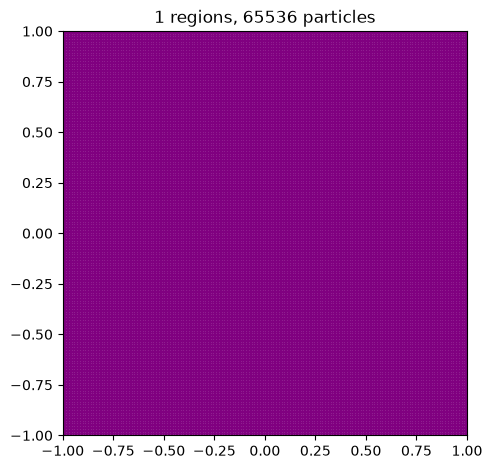

In [4]:
# What was actually built: the sampled regions, fluid and boundary, against the
# domain (black) the run is periodic in. This is the cell to look at when a
# geometry parameter above did something other than what it sounded like.
figure, axis = plt.subplots(1, 1, figsize=(5, 5), squeeze=False)
plotRegions(ctx.scratch['regions'], axis[0, 0], plotFluid=True, plotParticles=True)
domain = ctx.config.domain
axis[0, 0].set_aspect('equal')
axis[0, 0].set_xlim(domain.min[0].item(), domain.max[0].item())
axis[0, 0].set_ylim(domain.min[1].item(), domain.max[1].item())
axis[0, 0].set_title(f'{len(ctx.scratch["regions"])} regions, '
                     f'{len(runningState.state.positions)} particles')
figure.tight_layout()

In [5]:
# Export/plot setup via the same generic hooks `warpSPH.runner.run()` uses
# internally -- nothing here is re-derived, only called explicitly.
ctx.exportPath = prepExport(spec.caseName, ctx.config, ctx.schemeConfig, ctx.scheme, ctx.exportFunction)
spec.save(os.path.join(ctx.exportPath, 'caseSpec.json'))
print(f'exporting to {ctx.exportPath}')

# Direct buildFieldPlotter(VELOCITY_DENSITY_FIELDS), not kolmogorovCase.setupPlot -- see the intro cell
# for why.
fields = VELOCITY_UID_FIELDS
ctx.plotMarkerSize = 0.01
fields[0].gridResolution = 1024
plotter = None
if spec.plot:
    ctx.imagePath = os.path.join(ctx.exportPath, 'images')
    os.makedirs(ctx.imagePath, exist_ok=True)
    plotter = buildFieldPlotter(ctx, runningState, fields, figsize=(20,10))

outFile = None
groups = None
if spec.store and spec.storeMode == 'trajectory':
    extraData = kolmogorovCase.extraData(ctx, runningState)
    outFile = createOutFile(ctx.exportPath)
    groups = writeInitialData(ctx.exportPath, outFile, ctx.scheme, ctx.config, ctx.schemeConfig,
                              spec, runningState, extraData=extraData, extraFields=kolmogorovCase.extraFields)

exporting to export/08-kolmogorovFlow_2026-08-14_14-07-18


RFBOutputContext()

Module warpSPHCore.radiusSearch.compactHash.wp_index cb8e58c load on device 'cuda:0' took 0.47 ms  (cached)
Module warpSPHCore.radiusSearch.compactHash.wp_hashCells 69952ab load on device 'cuda:0' took 0.43 ms  (cached)
Module warpSPHCore.coreOperations.wp_interpolate 468de7c load on device 'cuda:0' took 2.33 ms  (cached)


In [6]:
# The step loop, visible and editable. This is the same call
# `warpSPH.runner.runner._run` makes internally, unrolled here so a
# perturbation or an extra diagnostic can be injected directly around it.
dt = ctx.config.dt if isinstance(ctx.config.dt, float) else ctx.config.dt.cpu().item()
nSteps = int(spec.tLimit / dt)
storeSteps = max(1, int(spec.exportInterval / dt)) if spec.storeMode == 'trajectory' \
    else max(1, spec.storeInterval)

trajectory = []

for i in (tq := tqdm(range(nSteps), leave=True)):
    # <-- hook point ---------------------------------------------------------
    stepResult = ctx.integrator.function(
        state=runningState, f=ctx.stepFunction, dt=ctx.config.dt,
        config=ctx.config, schemeConfig=ctx.schemeConfig, verbose=False,
    )
    runningState = stepResult.state
    # -------------------------------------------------------------------------

    tScalar = runningState.t.item() if torch.is_tensor(runningState.t) else runningState.t
    row = kolmogorovCase.diagnostics(ctx, runningState)
    trajectory.append(dict(row, step=i, t=tScalar))
    tq.set_description(f"t: {tScalar:.4f}, " + ", ".join(f"{k}: {v:.4f}" for k, v in row.items()))

    if plotter is not None and (i % spec.plotInterval == 0 or i == nSteps - 1):
        refreshFieldPlotter(ctx, runningState, plotter, fields, step=i)

    if outFile is not None and (i % storeSteps == 0 or i == nSteps - 1):
        writeFrame(groups, i, stepResult.state, stepResult.stages, config=ctx.config,
                  schemeConfig=ctx.schemeConfig, uniqueParticles=True, writeStages=False,
                  extraFields=kolmogorovCase.extraFields)

  0%|          | 0/40000 [00:00<?, ?it/s]

Module warpSPHCore.radiusSearch.compactHash.wp_countNeighbors b9d3a6a load on device 'cuda:0' took 0.64 ms  (cached)
Module warpSPHCore.radiusSearch.compactHash.wp_collectNeighbors ed2da4a load on device 'cuda:0' took 0.64 ms  (cached)
Module warpSPH.modules.util.wp_numNeighbors 29c3ba8 load on device 'cuda:0' took 1.15 ms  (cached)
Module warpSPHCore.coreOperations.wp_covariance 50e9353 load on device 'cuda:0' took 2.22 ms  (cached)
Module warpSPHCore.pinv.wp_pinv2x2 76f0431 load on device 'cuda:0' took 0.39 ms  (cached)
Module warpSPHCore.coreOperations.wp_gradient 2f20b75 load on device 'cuda:0' took 2.17 ms  (cached)
Module warpSPH.modules.deltaSPH.wp_densityDelta 4bf14b7 load on device 'cuda:0' took 1.84 ms  (cached)
Module warpSPH.modules.deltaSPH.wp_viscosityDelta 29a719b load on device 'cuda:0' took 1.77 ms  (cached)
Module warpSPHCore.coreOperations.wp_divergence a438168 load on device 'cuda:0' took 2.16 ms  (cached)
Module warpSPH.modules.pressure.wp_surfaceAware 837a75d load

KeyboardInterrupt: 

In [7]:
if outFile is not None:
    outFile.close()

if spec.plot:
    encodeFrames(ctx.imagePath, ctx.exportPath)

[png @ 0x5af64d551e00] chunk too big
[vist#0:0/png @ 0x5af64d15a4c0] Decoding error: Invalid data found when processing input


## The mean profile against the forcing

The one measurement this case is about: whether the flow is still following the
profile it is being driven to, or has gone unstable and left it.

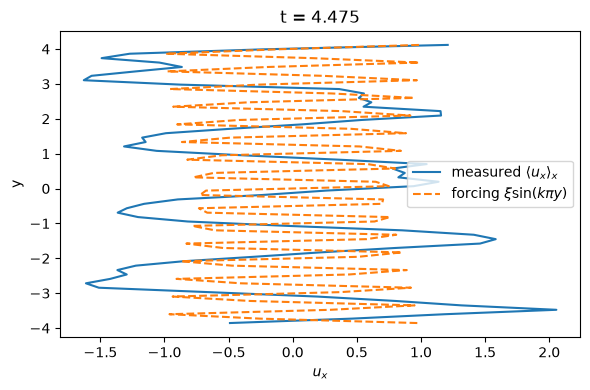

In [8]:
# The forcing profile the run is driven by, and what the flow actually settled
# into: `u_x` binned against `y`, against `xi * sin(k * pi * y)`. Early in the
# run they agree; once the shear layers go unstable the measured profile
# flattens between the layers, which is the instability.
positions = runningState.state.positions.detach().cpu().numpy()
velocities = runningState.state.velocities.detach().cpu().numpy()

y = np.linspace(positions[:, 1].min(), positions[:, 1].max(), 64)
index = np.clip(np.digitize(positions[:, 1], y) - 1, 0, len(y) - 1)
measured = np.array([velocities[index == i, 0].mean() if (index == i).any() else np.nan
                     for i in range(len(y))])

figure, axis = plt.subplots(1, 1, figsize=(6, 4))
axis.plot(measured, y, label=r'measured $\langle u_x \rangle_x$')
axis.plot(spec.param('xi') * np.sin(spec.param('k') * np.pi * y), y, ls='--',
          label=r'forcing $\xi \sin(k \pi y)$')
axis.set_xlabel(r'$u_x$'); axis.set_ylabel('y'); axis.legend()
axis.set_title(f't = {float(runningState.t):.3f}')
figure.tight_layout()

## The usual weakly compressible check

Kinetic energy is the more interesting panel here than in the other cases: the
forcing is a source, so it rises from zero and then plateaus when the
instability starts dissipating as fast as the forcing injects.

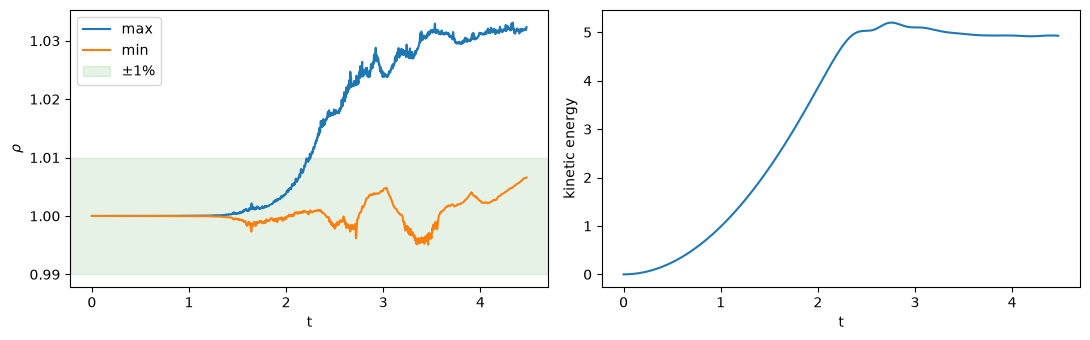

In [9]:
# The two numbers worth reading off any weakly compressible run: the density
# has to stay within about a percent of `rho0` (that is the whole premise of
# the scheme), and the kinetic energy says whether the flow is doing what it
# was set up to do. Both come from `weaklyCompressibleDiagnostics`, recorded
# every step in the loop above.
figure, axis = plt.subplots(1, 2, figsize=(11, 3.5))
t = [row['t'] for row in trajectory]
axis[0].plot(t, [row['maxDensity'] for row in trajectory], label='max')
axis[0].plot(t, [row['minDensity'] for row in trajectory], label='min')
axis[0].axhspan(0.99, 1.01, color='green', alpha=0.1, label=r'$\pm 1\%$')
axis[0].set_xlabel('t'); axis[0].set_ylabel(r'$\rho$'); axis[0].legend()
axis[1].plot(t, [row['kineticEnergy'] for row in trajectory])
axis[1].set_xlabel('t'); axis[1].set_ylabel('kinetic energy')
figure.tight_layout()